# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [1]:
import sys
print(sys.executable)

/home/brookewd/ai/projects/tinyml-arduino/bin/python


In [2]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

2026-05-20 21:21:39.785374: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-20 21:21:39.885137: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-20 21:21:40.671189: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-20 21:21:40.671356: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-20 21:21:40.673638: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [5]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [6]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

# <-- Enter your code here <--#

X = df.iloc[:, 1:]

y = df.iloc[:,0]
#print(y)


In [7]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

# <-- Enter your code here <--#

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

# <-- Enter your code here <--#

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

# <-- Enter your code here <--#

y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

# <-- Enter your code here <--#

model = keras.Sequential(
    [
        keras.Input(shape=(num_features)),
        layers.Dense(64, activation="relu", name="h1"),
        layers.Dense(32, activation="relu", name="h2"),
        layers.Dense(num_classes, activation="softmax", name="output")
    ]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 h1 (Dense)                  (None, 64)                896       
                                                                 
 h2 (Dense)                  (None, 32)                2080      


2026-05-20 21:21:49.779730: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-20 21:21:49.780446: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


                                                                 
 output (Dense)              (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

# <-- Enter your code here <--#

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=8,
    epochs=20,
    callbacks=callbacks,
    validation_split=0.2,
)


Epoch 1/20
13/13 [==============================] - 0s 32ms/step - loss: 0.9008 - accuracy: 0.6667 - val_loss: 0.7688 - val_accuracy: 0.8400
Epoch 2/20
13/13 [==============================] - 0s 7ms/step - loss: 0.6304 - accuracy: 0.9192 - val_loss: 0.5636 - val_accuracy: 0.8800
Epoch 3/20
13/13 [==============================] - 0s 8ms/step - loss: 0.4459 - accuracy: 0.9697 - val_loss: 0.4208 - val_accuracy: 0.8800
Epoch 4/20
13/13 [==============================] - 0s 11ms/step - loss: 0.3173 - accuracy: 0.9798 - val_loss: 0.3217 - val_accuracy: 0.8800
Epoch 5/20
13/13 [==============================] - 0s 9ms/step - loss: 0.2334 - accuracy: 0.9798 - val_loss: 0.2524 - val_accuracy: 0.9200
Epoch 6/20
13/13 [==============================] - 0s 9ms/step - loss: 0.1802 - accuracy: 0.9899 - val_loss: 0.2016 - val_accuracy: 0.9200
Epoch 7/20
13/13 [==============================] - 0s 6ms/step - loss: 0.1365 - accuracy: 0.9899 - val_loss: 0.1633 - val_accuracy: 0.9600
Epoch 8/20
13/13 [

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

2/2 [==============================] - 0s 10ms/step
Test Accuracy: 1.0000
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



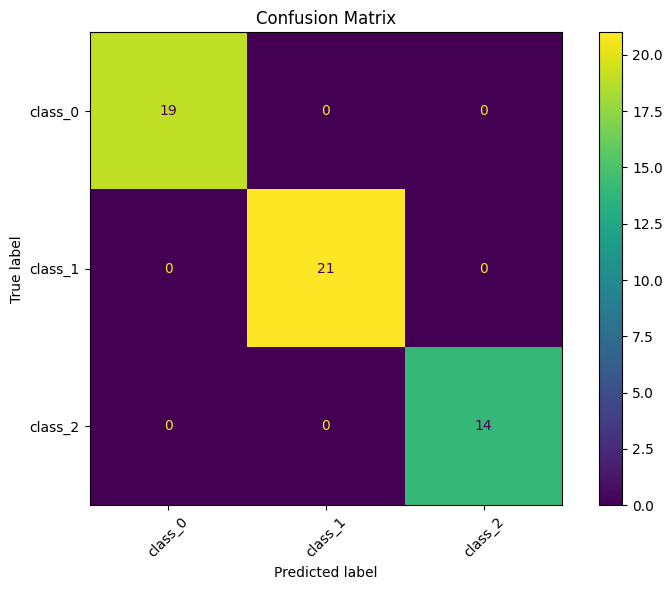

In [14]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

# <-- Enter your code here <--#

class_names = list(wine.target_names)

y_prob = model.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_prob, axis=1)

test_accuracy = np.mean(y_pred == y_test_labels)
print(f"Test Accuracy: {test_accuracy:.4f}")

print(classification_report(y_test_labels, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_labels, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
import os

In [16]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

path = "model_base.tflite"
with open(path, "wb") as f:
    f.write(tflite_model)
size= os.path.getsize(path) / 1024 
print(f"size: {size} KB")


INFO:tensorflow:Assets written to: /tmp/tmph5w_4fuo/assets


INFO:tensorflow:Assets written to: /tmp/tmph5w_4fuo/assets


size: 14.02734375 KB


2026-05-20 21:21:56.248173: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 21:21:56.248284: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 21:21:56.249612: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmph5w_4fuo
2026-05-20 21:21:56.252311: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 21:21:56.252358: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmph5w_4fuo
2026-05-20 21:21:56.264262: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-20 21:21:56.265392: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 21:21:56.323713: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmph5w_4fuo
2026-05

## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [17]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]


def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == 'int8':
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        # <-- Enter your code here <--#
        converter.optimizations  = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = tf.lite.RepresentativeDataset(
            lambda: representative_data_gen(X_test) #X_train_scaled doesn't exist bro what
        )
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        pass

    elif quant_type == 'float16':
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].
        # <-- Enter your code here <--#
        converter.optimize = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
        pass

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations.

        # <-- Enter your code here <--#
        converter.optimize = [tf.lite.Optimize.DEFAULT]        
        pass

    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert the model and save it to the provided filename.
    # <-- Enter your code here <--#
    path = f"{filename}.tflite"
    tflite_model = converter.convert()
    with open(path, 'wb') as f:
        f.write(tflite_model)
    size = os.path.getsize(path) / 1024

    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    # <-- Enter your code here for TFLite inference <--#
    interpreter = tf.lite.Interpreter(model_path = path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_scale, input_zero_point = input_details[0]['quantization']
    output_scale, output_zero_point = output_details[0]['quantization']

    y_pred = []
    y_true = np.argmax(y_test_cat, axis=1)

    for i in range(len(X_test)):
        sample = X_test[i:i+1].astype(np.float32)
        if (input_details[0]['dtype'] == np.int8):
            sample = (sample / input_scale + input_zero_point).astype(np.int8)
        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])
        if(output_details[0]['dtype'] == np.int8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        y_pred.append(np.argmax(output))

    y_pred = np.array(y_pred)

    # Step 4: Report results.
    #print(f"\n{quant_type.upper()} TFLite model size: {file_size_kb(filename):.2f} KB")
    print(f"\n{quant_type.upper()} TFLite model size: {size:.2f} KB")
    
    # <-- Enter your code here: print classification_report and confusion_matrix <--#

    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))


In [18]:
# Step 5: Use the function above to create and evaluate three quantized models:
# - 'int8' saved as 'model_int8.tflite'
int8 = quantize_and_evaluate(model, X_test, y_test, quant_type = 'int8', filename = 'model_int8')

# - 'float16' saved as 'model_float16.tflite'
float16 = quantize_and_evaluate(model, X_test, y_test, quant_type = 'float16', filename = 'model_float16')

# - 'dynamic' saved as 'model_dynamic.tflite'
dynamic = quantize_and_evaluate(model, X_test, y_test, quant_type = 'dynamic', filename = 'model_dynamic')



INFO:tensorflow:Assets written to: /tmp/tmp7izu1u0o/assets


INFO:tensorflow:Assets written to: /tmp/tmp7izu1u0o/assets
/home/brookewd/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-20 21:21:58.883773: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 21:21:58.883900: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 21:21:58.884135: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7izu1u0o
2026-05-20 21:21:58.885163: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 21:21:58.885207: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7izu1u0o
2026-05-20 21:21:58.888391: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.



INT8 TFLite model size: 5.70 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
INFO:tensorflow:Assets written to: /tmp/tmpi1t13tgv/assets


INFO:tensorflow:Assets written to: /tmp/tmpi1t13tgv/assets
2026-05-20 21:22:01.512669: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 21:22:01.512756: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 21:22:01.512986: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpi1t13tgv
2026-05-20 21:22:01.513733: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 21:22:01.513748: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpi1t13tgv
2026-05-20 21:22:01.516363: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 21:22:01.559601: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpi1t13tgv
2026-05-20 21:22:01.571687: I tensorflow/cc/saved_model/loader.cc:316] SavedModel


FLOAT16 TFLite model size: 14.03 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
INFO:tensorflow:Assets written to: /tmp/tmpyzw4vq04/assets


INFO:tensorflow:Assets written to: /tmp/tmpyzw4vq04/assets



DYNAMIC TFLite model size: 14.03 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


2026-05-20 21:22:03.951626: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 21:22:03.951731: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 21:22:03.952022: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpyzw4vq04
2026-05-20 21:22:03.953117: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 21:22:03.953137: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpyzw4vq04
2026-05-20 21:22:03.956586: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 21:22:04.010670: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpyzw4vq04
2026-05-20 21:22:04.025454: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 73433 m

## Problem 1 - Part (c)

### Pruning

In [40]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)

# <-- Enter your code here <--#

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity = 0.5,
    final_sparsity = 0.7,
    begin_step=0,
    end_step = len(X_train) // 8 * 9,
)


In [42]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

# <-- Enter your code here <--#

pruning_params = {
    'pruning_schedule': pruning_schedule,
    'block_size': (1, 1),
    'block_pooling_type': 'AVG'
}

model_pruned = tfmot.sparsity.keras.prune_low_magnitude(
    keras.Sequential([
        keras.Input(shape=(X_train.shape[1])),
        layers.Dense(64, activation="relu", name="h1"),
        layers.Dense(32, activation="relu", name="h2"),
        #layers.Dense(3, activation="relu", name="h3"),
        layers.Dense(num_classes, activation="softmax", name="output")
    ]), **pruning_params)

In [43]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

# <-- Enter your code here <--#

model_pruned.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'],
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history_pruned = model_pruned.fit(
    x=X_train,
    y=y_train,
    batch_size=8,
    epochs=10,
    callbacks=callbacks,
    validation_split=0.2,
)

Epoch 1/10
13/13 [==============================] - 8s 59ms/step - loss: 0.9926 - accuracy: 0.5051 - val_loss: 0.8311 - val_accuracy: 0.7600
Epoch 2/10
13/13 [==============================] - 0s 10ms/step - loss: 0.7390 - accuracy: 0.8485 - val_loss: 0.6282 - val_accuracy: 0.9200
Epoch 3/10
13/13 [==============================] - 0s 12ms/step - loss: 0.5557 - accuracy: 0.9495 - val_loss: 0.4794 - val_accuracy: 0.9200
Epoch 4/10
13/13 [==============================] - 0s 17ms/step - loss: 0.4102 - accuracy: 0.9697 - val_loss: 0.3654 - val_accuracy: 0.9200
Epoch 5/10
13/13 [==============================] - 0s 11ms/step - loss: 0.2942 - accuracy: 0.9697 - val_loss: 0.2790 - val_accuracy: 0.9200
Epoch 6/10
13/13 [==============================] - 0s 10ms/step - loss: 0.2069 - accuracy: 0.9697 - val_loss: 0.2250 - val_accuracy: 0.9200
Epoch 7/10
13/13 [==============================] - 0s 16ms/step - loss: 0.1519 - accuracy: 0.9596 - val_loss: 0.2003 - val_accuracy: 0.9200


In [46]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

# <-- Enter your code here <--#

model_stripped = tfmot.sparsity.keras.strip_pruning(model_pruned)

converter = tf.lite.TFLiteConverter.from_keras_model(model_stripped)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

path = "model_pruned.tflite"
tflite_model = converter.convert()
with open(path, 'wb') as f:
    f.write(tflite_model)
size = os.path.getsize(path) / 1024

print(f"Pruned model is {size} KB")


INFO:tensorflow:Assets written to: /tmp/tmpipik0d58/assets


INFO:tensorflow:Assets written to: /tmp/tmpipik0d58/assets


Pruned model is 8.140625 KB


2026-05-20 22:14:34.410646: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 22:14:34.410752: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 22:14:34.411045: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpipik0d58
2026-05-20 22:14:34.413210: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 22:14:34.413274: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpipik0d58
2026-05-20 22:14:34.415924: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 22:14:34.450196: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpipik0d58
2026-05-20 22:14:34.463593: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 52549 m

2/2 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



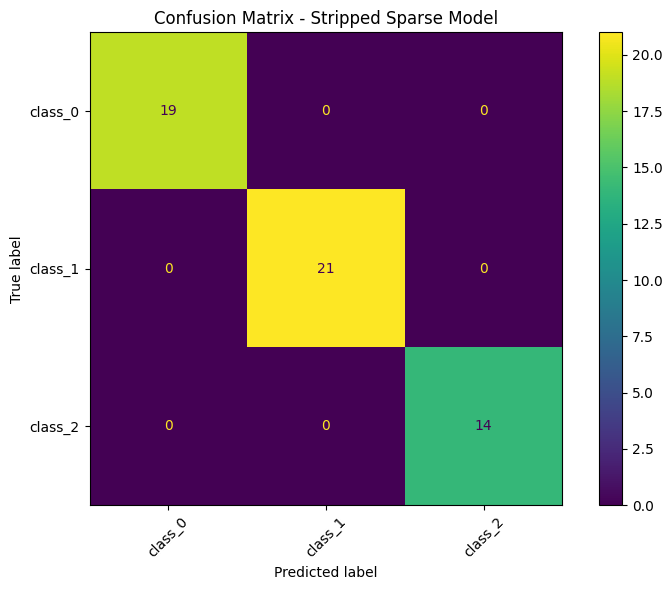

In [47]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

cm_strip = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_strip, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Stripped Sparse Model")
plt.tight_layout()
plt.show()

## Problem 1 - Part (d)

### Knowledge Distillation

In [24]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

# <-- Enter your code here <--#

student_model = keras.Sequential(
    [
        keras.Input(shape=(num_features)),
        layers.Dense(32, activation="relu", name="h1"),
        layers.Dense(16, activation="relu", name="h2"),
        layers.Dense(num_classes, activation="softmax", name="output")
    ]
)

In [31]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels
teacher_labels = model.predict(X_train)
# <-- Enter your code here <--#

4/4 [==============================] - 0s 4ms/step


In [35]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels

# <-- Enter your code here <--#
y_true_combined = np.concatenate([y_train, teacher_labels], axis=1)

alpha = 0.5
def distillation_loss(y_true_combined, y_pred):
    y_true_hard = y_true_combined[:, :num_classes]
    y_true_soft = y_true_combined[:, num_classes:]

    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)

    return alpha * hard_loss + (1 - alpha) * soft_loss

    # <-- Enter your code here: implement hard/soft label separation and weighted loss <--#
    pass

In [36]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

# <-- Enter your code here <--#

student_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=distillation_loss,
    metrics=['accuracy']
)

history_student = student_model.fit(
    x=X_train,
    y=y_true_combined,
    batch_size=8,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
13/13 [==============================] - 4s 66ms/step - loss: 1.1670 - accuracy: 0.4141 - val_loss: 0.9544 - val_accuracy: 0.5200
Epoch 2/10
13/13 [==============================] - 0s 11ms/step - loss: 0.8054 - accuracy: 0.6768 - val_loss: 0.7038 - val_accuracy: 0.8000
Epoch 3/10
13/13 [==============================] - 0s 11ms/step - loss: 0.6191 - accuracy: 0.8182 - val_loss: 0.5571 - val_accuracy: 0.9200
Epoch 4/10
13/13 [==============================] - 0s 10ms/step - loss: 0.5093 - accuracy: 0.9091 - val_loss: 0.4634 - val_accuracy: 1.0000
Epoch 5/10
13/13 [==============================] - 0s 10ms/step - loss: 0.4341 - accuracy: 0.9192 - val_loss: 0.4003 - val_accuracy: 1.0000
Epoch 6/10
13/13 [==============================] - 0s 9ms/step - loss: 0.3815 - accuracy: 0.9192 - val_loss: 0.3542 - val_accuracy: 1.0000
Epoch 7/10
13/13 [==============================] - 0s 11ms/step - loss: 0.3436 - accuracy: 0.9394 - val_loss: 0.3219 - val_accuracy: 1.0000
Epoch 8/10
13/

In [37]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(student_model)
tflite_model = converter.convert()

path = "model_kd.tflite"
with open(path, "wb") as f:
    f.write(tflite_model)
size= os.path.getsize(path) / 1024 
print(f"size: {size} KB")


INFO:tensorflow:Assets written to: /tmp/tmp1l03oyqz/assets


INFO:tensorflow:Assets written to: /tmp/tmp1l03oyqz/assets


size: 6.0390625 KB


2026-05-20 21:41:27.239099: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 21:41:27.243148: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 21:41:27.256118: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1l03oyqz
2026-05-20 21:41:27.257983: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 21:41:27.258082: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1l03oyqz
2026-05-20 21:41:27.275768: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 21:41:27.471923: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1l03oyqz
2026-05-20 21:41:27.504343: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 245695 

2/2 [==============================] - 1s 83ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



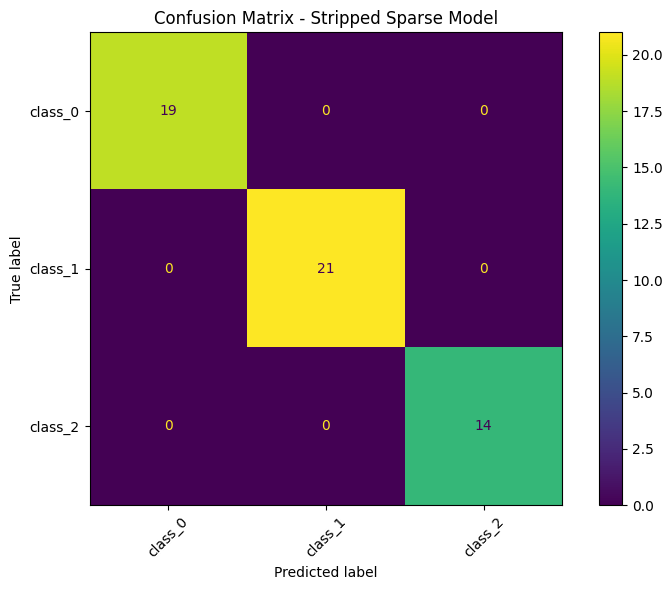

In [38]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#

y_pred = np.argmax(student_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))
cm_strip = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_strip, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Stripped Sparse Model")
plt.tight_layout()
plt.show()



## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


Epoch 1/10
13/13 [==============================] - 9s 82ms/step - loss: 0.2343 - accuracy: 0.9798 - val_loss: 0.2471 - val_accuracy: 1.0000
Epoch 2/10
13/13 [==============================] - 0s 14ms/step - loss: 0.2236 - accuracy: 0.9899 - val_loss: 0.2478 - val_accuracy: 1.0000
Epoch 3/10
13/13 [==============================] - 0s 12ms/step - loss: 0.2187 - accuracy: 0.9899 - val_loss: 0.2464 - val_accuracy: 1.0000
Epoch 4/10
13/13 [==============================] - 0s 9ms/step - loss: 0.2145 - accuracy: 0.9899 - val_loss: 0.2454 - val_accuracy: 1.0000
Epoch 5/10
13/13 [==============================] - 0s 8ms/step - loss: 0.2125 - accuracy: 0.9899 - val_loss: 0.2448 - val_accuracy: 1.0000
Epoch 6/10
13/13 [==============================] - 0s 9ms/step - loss: 0.2109 - accuracy: 1.0000 - val_loss: 0.2444 - val_accuracy: 1.0000
INFO:tensorflow:Assets written to: /tmp/tmpzu6i8w9e/assets


INFO:tensorflow:Assets written to: /tmp/tmpzu6i8w9e/assets
2026-05-20 22:33:37.561438: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 22:33:37.564190: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 22:33:37.575452: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpzu6i8w9e
2026-05-20 22:33:37.577823: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 22:33:37.577888: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpzu6i8w9e
2026-05-20 22:33:37.595357: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 22:33:37.681984: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpzu6i8w9e
2026-05-20 22:33:37.695820: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Pruned Student model is 6.04296875 KB
2/2 [==============================] - 0s 12ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



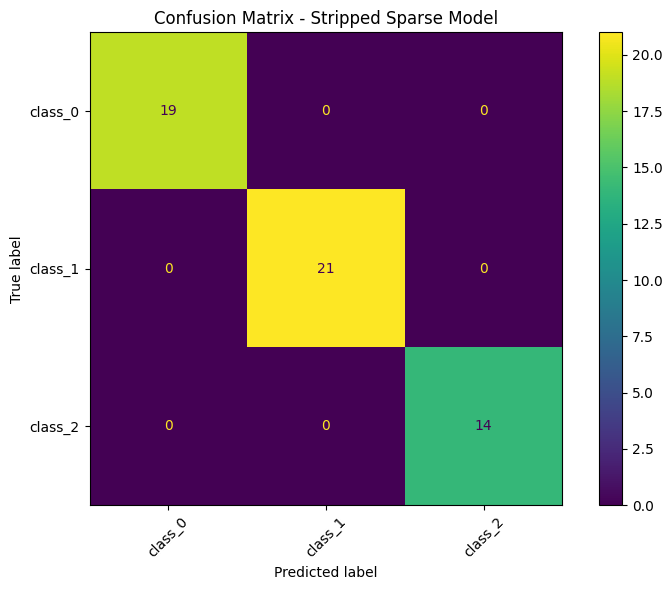

In [53]:
# <-- (if needed) Enter your code here <--#

#wrap
student_pruned = tfmot.sparsity.keras.prune_low_magnitude(student_model,  pruning_schedule=pruning_schedule)

#setup
student_pruned.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=distillation_loss,
    metrics=['accuracy'],
)
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]
history_pruned_student = student_pruned.fit(
    x=X_train,
    y=y_true_combined,
    batch_size=8,
    epochs=10,
    callbacks=callbacks,
    validation_split=0.2,
)

#
student_stripped = tfmot.sparsity.keras.strip_pruning(student_pruned)

converter = tf.lite.TFLiteConverter.from_keras_model(student_stripped)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

#check size and accuracy
path = "student_stripped.tflite"
tflite_model = converter.convert()
with open(path, 'wb') as f:
    f.write(tflite_model)
size = os.path.getsize(path) / 1024

print(f"Pruned Student model is {size} KB")

y_pred = np.argmax(student_stripped.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred))
cm_strip = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_strip, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Stripped Sparse Model")
plt.tight_layout()
plt.show()



In [52]:
#int8-ify
student_stripped_int8 = quantize_and_evaluate(student_stripped, X_test, y_test, quant_type = 'int8', filename = 'student_stripped_int8')




INFO:tensorflow:Assets written to: /tmp/tmpmriq1zpr/assets


INFO:tensorflow:Assets written to: /tmp/tmpmriq1zpr/assets



INT8 TFLite model size: 3.56 KB
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


/home/brookewd/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-20 22:22:35.818924: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 22:22:35.819030: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 22:22:35.819287: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpmriq1zpr
2026-05-20 22:22:35.820118: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 22:22:35.820141: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpmriq1zpr
2026-05-20 22:22:35.823245: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 22:22:35.850547: I tensorflow/cc/saved_model/loa

# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
